# Lecture 6 - Numerical Differentiation and Integration

Frequently when one is doing calculations, one does not have an analytic expression to take the derivative or integral of, or possible analytic expressions that one might derive are unreasonably complicated and unweildy. In these cases, one can use numerical algorithms to approximate derivatives and integrals that one either gets after carying out a calculation on a computer, or by carrying out this operation on data. Today, we will be discussing these algorithms

We will first discuss how to calculate a derivative. Although one can develop algorithms that minimize the truncation error even further, in practice these more complicated approaches are rarely implemented for a variety of reasons (too much roundoff error, numerical stability, restrictive assumptions on the underlying function, etc.)

We will next discuss methods to numerically approximate an integral. Although the primary method used (Simpson's method) has a similar truncation error as the derivative method we discuss (centered differencing), the derivation underlying this method's implementation are more subtle. We will spend more time on it.

To accept this assignment on Classroom 50 with your GitHub profile enrolled in the class, click on the link\
**insert link** \
and follow the steps the webpage prompts.

To submit this assignment, follow the steps in "First time Classroom 50 setup" and "Accepting and Submitting Assignments" on the course webpage: \
https://psuastro410.github.io/tips/github/

### Resources and Acknowledgements

This lecture uses material from the following sources:\
https://zingale.github.io/computational_astrophysics/basics/diff-int/differentiation.html \
https://zingale.github.io/computational_astrophysics/basics/diff-int/integration.html \
https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter20.00-Numerical-Differentiation.html \
https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/chapter21.00-Numerical-Integration.html \

# Differentiation

There are two situations where we can imagine needing to compute a derivative:

1. We have an analytic function, $f(x)$, and we want to create a
numerical approximation to its derivative

2. We have a function $f(x)$ defined only at a finite set of (possibly regularly spaced) points, and we want to use that discrete data to estimate the derivative

For the first case, it is usually best to take the analytic derivative.  In the previous notebook however, we did look at the effect of roundoff on computing a derivative.

We'll focus on the second case here, but note that this can be applied to the case where the function is known analytically provided we evaluate it at a fixed set of points.

## First order approximations

Consider a set of points labeled with an index $i$, with the physical spacing between them denoted $\Delta x$.

![fd_grid](https://zingale.github.io/computational_astrophysics/_images/fd_grid.png)

We'll label the function value at $x_i$ as $f_i$, e.g., $f_i = f(x_i)$.

We can use the result of the Taylor expansion we previously derived to write the derivative as:

$$\left . \frac{d f}{dx} \right |_i = \frac{f_{i+1} - f_i}{\Delta x} + \mathcal{O}(\Delta x)$$

where $f_{i+1} = f(x_{i+1})$ is the data we have at the point $i+1$.  

As $\Delta x \rightarrow 0$, this approaches the definition of the derivative from calculus.  However, we are not free to choose $\Delta x$&mdash;it is a property of the discrete set of points we are given.

Note: we could alternately have used the point to the right of $i$:

$$\left . \frac{d f}{dx} \right |_i = \frac{f_{i} - f_{i-1}}{\Delta x} + \mathcal{O}(\Delta x)$$

## Second order approximation

Looking at the Taylor expansion of $f_{i+1} = f(x_{i+1}) = f(x_i + \Delta x)$, we see

$$f_{i+1} = f_i + \Delta x \left .\frac{df}{dx} \right |_i + \frac{1}{2} \Delta x^2 \left . \frac{d^2f}{dx^2} \right |_i + \mathcal{O}(\Delta x^3)$$

likewise:

$$f_{i-1} = f_i - \Delta x \left .\frac{df}{dx} \right |_i + \frac{1}{2} \Delta x^2 \left . \frac{d^2f}{dx^2} \right |_i + \mathcal{O}(\Delta x^3)$$

subtracting these two expressions give:

$$f_{i+1} - f_{i-1} = 2 \Delta x \left . \frac{df}{dx} \right |_i + \mathcal{O}(\Delta x^3)$$

or

$$\left . \frac{df}{dx} \right |_i = \frac{f_{i+1} - f_{i-1}}{2 \Delta x} +\mathcal{O}(\Delta x^2)$$

This is called the *centered-difference* approximation to the first derivative.  It is second order accurate.

Graphically, these different approximations appear as:

![derivs](https://zingale.github.io/computational_astrophysics/_images/derivs.png)

**Example:** Consider the function $f(x) = \sin(x)$.  The code below defines 10 equally spaced points and defines $f(x)$ at each point. 

Use this discrete data to estimate the derivative at `x[3]` and compute the error with respect to the analytic value.

In [2]:
import numpy as np

x = np.linspace(0, np.pi, 10, endpoint=False)
f = np.sin(x)

# first we'll write functions to evaluate each of the
# derivative approximations at a given index idx

def left_sided_deriv(x, f, idx):
    """return the left-sided derivative at x[idx]"""
    return (f[idx] - f[idx-1]) / (x[idx] - x[idx-1])

def right_sided_deriv(x, f, idx):
    """return the right-sided derivative at x[idx]"""
    return (f[idx+1] - f[idx]) / (x[idx+1] - x[idx])

def centered_deriv(x, f, idx):
    """return the left-sided derivative at x[idx]"""
    return (f[idx+1] - f[idx-1]) / (x[idx+1] - x[idx-1])

# always use x[ival] for the location of the derivative
ival = 3

dl = left_sided_deriv(x, f, ival)
dr = right_sided_deriv(x, f, ival)
dc = centered_deriv(x, f, ival)

print(f"left     = {dl}")
print(f"right    = {dr}")
print(F"centered = {dc}")
print(f"analytic = {np.cos(x[ival])}")

left     = 0.7042025064251414
right    = 0.4521258405602084
centered = 0.5781641734926749
analytic = 0.5877852522924731


## Convergence

Now we can see if we get the convergence that truncation error suggests.  We'll look at the centered difference.  As we cut $h$ in half, the error should go down by $1/4$.

In [3]:
def derivative(x0, f, h):
    """compute the derivative of the function f(x) at x0 using stepsize h"""
    return (f(x0 + h) - f(x0 - h)) / (2 * h)

def func(x):
    return np.sin(x)

def fprime(x):
    return np.cos(x)

h = 0.1
x0 = 1.0
while h > 1.e-5:
    err = np.abs(derivative(x0, func, h) - fprime(x0))
    print(f"{h:10.6g} : {err:20.10g}")
    
    h /= 2

       0.1 :      0.0009000536984
      0.05 :      0.0002250978217
     0.025 :      5.627973142e-05
    0.0125 :      1.407026262e-05
   0.00625 :      3.517586261e-06
  0.003125 :      8.793978465e-07
 0.0015625 :       2.19849555e-07
0.00078125 :      5.496242883e-08
0.000390625 :      1.374043412e-08
0.000195313 :      3.435006501e-09
9.76563e-05 :      8.588627587e-10
4.88281e-05 :       2.14826823e-10
2.44141e-05 :      5.339151343e-11
1.2207e-05 :       1.01905151e-11


## In-class Example: Second Derivative

Let's construct a difference approximation to the second derivative.

We'll use the same Taylor expansions as before, but now we'll include more terms:

$$f(x\pm h) = f(x) \pm f^\prime(x) h + \frac{1}{2} f^{\prime\prime}(x) h^2  \pm \frac{1}{6} f^{\prime\prime\prime}(x) h^3 + \mathcal{O}(h^4)$$

Now, let's eliminate the first derivative by combining these as:

$$f(x+h) + f(x-h) = 2 f(x) + f^{\prime\prime}(x) h^2 + \mathcal{O}(h^4)$$

Notice that the third-derivative term also cancels.

We can now solve for the second derivative:

$$f^{\prime\prime}(x) = \frac{f(x+h) - 2 f(x) + f(x-h)}{h^2} + \mathcal{O}(h^2)$$

We expect this to be _second-order accurate_.

In the **exercises below**, we will implement this and test its convergence on $f(x) = \sin(x)$.

# Integration

As with derivatives, there are two cases where we need to do integrals:

1. We are given a function $f(x)$ and are free to evaluate it wherever we wish to compute the integral in a domain $[a,b]$.

2. We are given $N$ points (possibly equally spaced) in $[a,b]$ and want to use them to construct the integral over the domain.

Today, we'll assume here that the discrete data we have is at equally spaced points, and we will treat cases 1 and 2 with the same methods. When the points are not equally-spaced, one can generalize these methods to apply to non equally-spaced data.

**Note:** In general, if you have the freedom to evaluate $f(x)$ at any $x$ (case 1), then you can usually get a far better estimate of the integral by carefully selecting the points to evaluate at, compared to using the same number of equally spaced points (see for instance [Gaussian quadrature](https://en.wikipedia.org/wiki/Gaussian_quadrature)).

In calculus, you saw a definition of a definite integral that looked something like:

$$
I \equiv \int_a^b f(x) dx = \lim_{\Delta x \rightarrow 0} \sum_{i = 1}^N f(x_i) \Delta x
$$

where the number of intervals you divide $[a, b]$ into, $N$, is defined such that $N = (b - a) / \Delta x$.  Also recall that this definition is directly related to the interpretation of an integral representing the area under a curve.

For numerical integration, we will replace the continuous integral with a sum over a finite number of points (we will not take the limit, since we can't sum over an infinite number of points on a computer in a finite amount of time).

**Note:** Any expression for an integral of the form:

$$
I \equiv \int_a^b f(x) dx \approx \sum_{i=1}^{N} w_i f(x_i)
$$

is called a *quadrature rule* in numerical analysis.  Here $w_i$ are the weights multiplying the function values.  Different quadrature rules will have different weights and have differing accuracy and convergence properties.

## Numerical integration approximations

We'll first look at the case where we represent the data using a low order polynomial and approximate the integral under the function as the area under the polynomial.  With evenly spaced points, these are sometimes called [Newton-Cotes quadrature rules](https://en.wikipedia.org/wiki/Newton%E2%80%93Cotes_formulas).

### Rectangle rule

The simplest method of doing a numerical integral is to approximate the function as a constant.  This means we use a single value of $f(x)$ to compute the integral.  For instance, we use $f(a)$, the value of the function at the leftmost point of the integration range.  This is called the *rectangle rule*:

$$
I_r = f(a) (b - a)
$$


Visually, this looks like:

![rectangle rule](https://zingale.github.io/computational_astrophysics/_images/rectangle_N1.png)

### Trapezoid rule

The rectangle rule did not account for any variation of $f(x)$ over the domain.  But we can do better simply by evaluating $f(x)$ at the endpoints of each domain and connecting them via a straight line&mdash;this is a linear interpolation.  Now we have a trapezoids, so the integral is just the area of the trapezoid, giving rise to the *trapezoid rule*.

$$
I_t = \frac{b - a}{2} (f(a) + f(b))
$$

Visually, this looks like:

![trapezoid rule](https://zingale.github.io/computational_astrophysics/_images/trapezoid_N1.png)

### Simpson's rule

With the trapezoid, we represented that data as a line in each slab.  We can move up to a parabola, but now we need 3 points, so we will use the midpoint of the domain as well.  We then compute the integral by integrating under the parabola.

$$
I_s = \frac{b - a}{6} \left [f(a) + 4 f\left (\frac{a+b}{2}\right ) + f(b) \right ]
$$

Visually, this looks like:

![Simpsons rule](https://zingale.github.io/computational_astrophysics/_images/simpsons_N1.png)

**Example:** Consider the function
    
$$
f(x) = 1 + \frac{x}{4} \sin(\pi x)
$$
 
(this is the function that is drawn in the figures).
Compute
    
$$
I = \int_{1/2}^{3/2} f(x) dx
$$
    
using the rectangle rule, trapezoid rule, and Simpson's rule.
    
We compare to the analytic result

$$
I = 1 - \frac{1}{2\pi^2} \approx 0.949
$$

In [5]:
import numpy as np

# define the function

def f(x):
    return 1 + 0.25 * x * np.sin(np.pi * x)

a = 0.5
b = 1.5

# compute the 3 different approximations

I_r = f(a) * (b - a)
I_t = 0.5 * (f(a) + f(b)) * (b - a)
I_s = (b - a) / 6.0 * (f(a) + 4 * f((a + b)/2) + f(b))

I_a = 1 - 1/(2 * np.pi**2)

print(f"Rectangle = {I_r}")
print(f"Trapezoid = {I_t}")
print(f"Simpson   = {I_s}")
print(f"Analytic  = {I_a}")

Rectangle = 1.125
Trapezoid = 0.875
Simpson   = 0.9583333333333333
Analytic  = 0.9493394081788311


**Question:** When might the Trapezoid rule be *better* than the Simpson rule?

# SymPy Example: Deriving Simpson's Rule

To get an analytic expression, one often has to do some tedious calculations. In the olden days, one had to do this all using pencil and paper. With computer algebra systems, much of the tedium can be carried out with the help of a computer.

In this example, we will demonstrate how to derive Simpson's Rule, with the aid of computer algebra systems.

In [6]:
from sympy import init_session
init_session(use_latex="mathjax")

IPython console for SymPy 1.13.2 (Python 3.12.2-64-bit) (ground types: python)

These commands were executed:
>>> from sympy import *
>>> x, y, z, t = symbols('x y z t')
>>> k, m, n = symbols('k m n', integer=True)
>>> f, g, h = symbols('f g h', cls=Function)
>>> init_printing()

Documentation can be found at https://docs.sympy.org/1.13.2/



We want to fit a parabola to 3 points: $(x_0, f_0)$, $(x_1, f_1)$, $(x_2, f_2)$ and then integrate under this fit.  We'll assume that these points are equally spaced, or $x_1 = x_0 + \Delta x$, and $x_2 = x_1 + \Delta x = x_0 + 2 \Delta x$.

We'll choose a polynomial of the form:

$$f(x) = a (x - x_0)^2 + b (x - x_0) + c$$

In [7]:
a, b, c = symbols("a b c")
x0 = symbols("x_0")
dx = symbols(r"\Delta{}x")
f0, f1, f2 = symbols("f_0 f_1 f_2")

f = a * (x - x0)**2 + b * (x - x0) + c

Now we can get 3 constraints by evaluating this at our 3 points

In [8]:
constraint_0 = Eq(f.subs(x, x0), f0)
constraint_0

c = f₀

In [9]:
constraint_1 = Eq(f.subs(x, x0 + dx), f1)
constraint_1

         2                         
\Delta{}x ⋅a + \Delta{}x⋅b + c = f₁

In [10]:
constraint_2 = Eq(f.subs(x, x0 + 2 * dx), f2)
constraint_2

           2                           
4⋅\Delta{}x ⋅a + 2⋅\Delta{}x⋅b + c = f₂

In [11]:
coeffs = solve([constraint_0, constraint_1, constraint_2], [a, b, c])
coeffs

⎧   f₀ - 2⋅f₁ + f₂     -3⋅f₀ + 4⋅f₁ - f₂       ⎫
⎪a: ──────────────, b: ─────────────────, c: f₀⎪
⎨               2         2⋅\Delta{}x          ⎬
⎪    2⋅\Delta{}x                               ⎪
⎩                                              ⎭

This shows that our polynomial is

$$f(x) = \frac{f_0 - 2 f_1 + f_2}{2 \Delta x^2} (x - x_0)^2 
      + \frac{-3 f_0 + 4 f_1 - f_2}{2 \Delta x} (x - x_0) + f_0$$

Now we can integrate under this from $[x_0, x_2]$ (or equivalently $[x_0, x_0 + 2 \Delta x]$

In [12]:
I = integrate(f.subs({a: coeffs[a], b: coeffs[b], c: coeffs[c]}),
              [x, x0, x0+2*dx])
simplify(I)

\Delta{}x⋅(f₀ + 4⋅f₁ + f₂)
──────────────────────────
            3             

This shows that the integral is:

$$I = \int_a^b f(x) dx \approx \frac{\Delta x}{3} \left [ f(a) + 4 f\left(\frac{a+b}{2}\right ) + f(b) \right ]$$

# Composite Integration

It usually doesn't pay to go to higher-order polynomials (e.g., fitting a cubic to 4 points in the domain).  Instead, we can do composite integration by dividing our domain $[a, b]$ into slabs, and then using the above approximations.

Here's an illustration of dividing the domain into 6 slabs:

![compound integration examples with N=6](https://zingale.github.io/computational_astrophysics/_images/compound2.png)

Imagine using $N$ slabs.
For the rectangle and trapezoid rules, we would apply them N times (once per slab) and sum up the integrals in each slab.
For the Simpson's rule, we would apply Simpson's rule over 2 slabs at a time and sum up the integrals over the $N/2$ pair of slabs (this assumes that $N$ is even).

The composite rule for trapezoid integration is:

$$
\int_a^b f(x) dx = \frac{\Delta x}{2} \sum_{i=0}^{N-1} (f_i + f_{i+1}) + \mathcal{O}(\Delta x^2)
$$

and for Simpson's rule, it is:

$$
\int_a^b f(x) dx = \frac{\Delta x}{3} \sum_{i = 0}^{N/2-1} (f_{2i} + 4 f_{2i+1} + f_{2i+2}) + \mathcal{O}(\Delta x^4)
$$

**Example:** For the function in the previous exercise, perform a composite integral using the trapezoid and Simpson's rule for $N = 2, 4, 8, 16, 32$.
Compute the error with respect to the analytic solution and make a plot of the error vs. $N$ for both methods.  Do the errors follow the scaling shown in the expressions above?

First, let's write the function we will integrate:

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return 1 + 0.25 * x * np.sin(np.pi * x)

Now our composite trapezoid and Simpson's rules.  These functions will take the number of bins, $N$, and the integration limits $[a, b]$ and then sample our function at $N+1$ points to do the composite integration.

In [15]:
def I_t(N, a, b, func):
    """composite trapezoid rule.  Here N is the number
    of bins, [a, b] are the integration limits, and
    func is the function to call."""
    
    I = 0.0
    x = np.linspace(a, b, N+1)
    
    # loop over bins
    for n in range(N):
        I += 0.5*(x[n+1] - x[n]) * (func(x[n]) + func(x[n+1]))
    return I

def I_s(N, a, b, func):
    """composite Simpsons rule.  Here N is the number
    of bins, [a, b] are the integration limits, and
    func is the function to call."""
    
    # we require an even number of bins
    assert N % 2 == 0
    
    I = 0.0
    x = np.linspace(a, b, N+1)
    
    # loop over bins
    for n in range(0, N-1, 2):
        dx = x[n+1] - x[n]
        I += dx/3.0 * (f(x[n])+ 4 * f(x[n+1]) + f(x[n+2]))
    return I

Now, lets put in the integration limits `a` and `b`, compare to the analytic solution saved as `I_a`, and run for a bunch of different number of bins and store the errors:

In [16]:
a = 0.5
b = 1.5
I_a = 1 - 1/(2 * np.pi**2)

# number of bins
N = [2, 4, 8, 16, 32, 64, 128, 256]

# keep track of the errors for each N
err_trap = []
err_simps = []

for nbins in N:
    err_trap.append(np.abs(I_t(nbins, a, b, f) - I_a))
    err_simps.append(np.abs(I_s(nbins, a, b, f) - I_a))

Now we'll plot the errors along with the expected scaling

Text(0, 0.5, 'error')

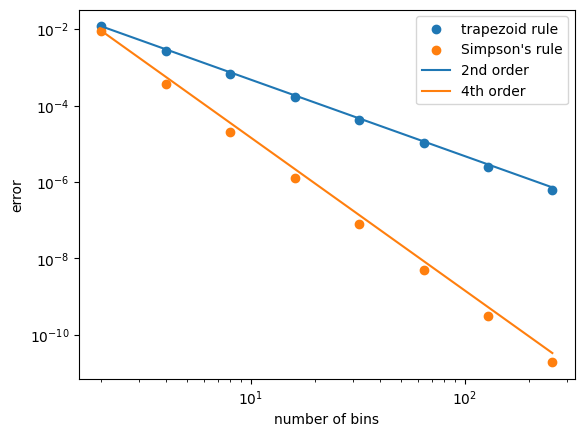

In [17]:
err_trap = np.asarray(err_trap)
err_simps = np.asarray(err_simps)
N = np.asarray(N)

fig = plt.figure()
ax = fig.add_subplot(111)

ax.scatter(N, err_trap, label="trapezoid rule")
ax.scatter(N, err_simps, label="Simpson's rule")

# compute the ideal scaling
# err = err_0 (N_0 / N) ** order
fourth_order = err_simps[0] * (N[0]/N)**4
second_order = err_trap[0] * (N[0]/N)**2

ax.plot(N, second_order, label="2nd order")
ax.plot(N, fourth_order, label="4th order")

ax.set_xscale("log")
ax.set_yscale("log")

ax.legend()
ax.set_xlabel("number of bins")
ax.set_ylabel("error")

**Warning:** As you make the number of bins larger and larger, eventually you'll hit a limit to how accurate you can get the integral (somewhere around N ~ 4096 bins for Simpson's).  Beyond that, roundoff error dominates.

# Exercises (10 pt)

### Exercise 1 (2 pt)

Write a function that calculates the second derivative of $f(x)$, using

$$f^{\prime\prime}(x) = \frac{f(x+h) - 2 f(x) + f(x-h)}{h^2} + \mathcal{O}(h^2)$$

In [1]:
## Answer here


### Exercise 2 (2 pt)

Calculate the second derivative of the function
$$
f(x) = \sin(x),
$$
for a specific step-size $h$. Compare the result to the analytic expression
$$
f_{\rm an}''(x) = -\sin(x)
$$
with a plot

In [3]:
## Answer here


### Exercise 3 (4 pt)

Some functions, particularlly periodic functions, can be written as an infinite sum of sine and cosine waves. For these functions,

 $$f(x)= \frac{A_0}{2}+\sum_{n=1}^{\infty}A_n\ \cos{(nx)} + B_n\ \sin{(nx)}$$

 It can be shown that the values of $A_n$ and $B_n$ can be computed using the following formulas:

 $$A_n= \frac{1}{\pi} \int_{-\pi}^{\pi} f(x) \cos{(nx)}\ dx$$
 $$B_n= \frac{1}{\pi} \int_{-\pi}^{\pi} f(x) \sin{(nx)}\ dx$$

Functions can be approximated by truncating the Fourier series at some $n = N$. Fourier series form the basis of many astronomical applications, such as signal processing and asteroseismology.

Write a function `my_fourier_coef(f, n)`, with output $[A_n, B_n]$, where $f$ is an function object that is $2\pi$-periodic. The function `my_fourier_coef` should compute the $n$-th Fourier coefficients, $A_n$ and $B_n$, in the Fourier series. Keep the function $f$ a general object that depends on $x$. Use either the Trapezoid rule or Simpson's rule to carry out the integral.

In [4]:
## Answer here


### Exercise 4 (2 pt)

Below is a script that uses `my_fourier_coef(f, n)` for the function
$$
f(x) = \sin(e^x):
$$

In [ ]:
def plot_results(f, N):
    x = np.linspace(-np.pi, np.pi, 10000)
    [A0, B0] = my_fourier_coef(f, 0)
    y = A0*np.ones(len(x))/2
    for n in range(1, N):
        [An, Bn] = my_fourier_coef(f, n)
        y += An*np.cos(n*x)+Bn*np.sin(n*x)
    plt.figure(figsize = (10,6))
    plt.plot(x, f(x), label = 'analytic')
    plt.plot(x, y, label = 'approximate')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.grid()
    plt.legend()
    plt.title(f'{N}th Order Fourier Approximation')
    plt.show()
    
f = lambda x: np.sin(np.exp(x))
N = 2
plot_results(f, N)

Plot the results for $N=2$, $N=5$, and $N=20$. How does the approximation converge to the true function? Where is the approximation good, and where are there errors?

In [5]:
## Code here


**Explanation here**
